# EDA & Data Cleaning
### Path to trustworthy data

NumPy, pandas, and matplotlib gave you the tools. This notebook is the first time we point them at a real dataset before any model gets near it: looking at the data, understanding what's really in it, and fixing what's broken. In practice this stage eats a large share of any ML project's time, and it's where silent bugs are born if it gets skipped.

## 0. Introduction

### 0.1 A quick taste: `.head()` isn't enough

In [1]:
import pandas as pd
import numpy as np

toy = pd.DataFrame({
    "city":  ["A", "A", "B", "B", "C"],
    "price": [100, 100, 200, np.nan, 150],
})
toy

ModuleNotFoundError: No module named 'pandas'

Nothing looks obviously wrong here. But there's a duplicated row (`"A", 100`) and a missing value (row 3). A quick systematic check catches both immediately:

In [3]:
print("missing values per column:\n", toy.isna().sum())
print("\nduplicated rows:", toy.duplicated().sum())

missing values per column:
 city     0
price    1
dtype: int64

duplicated rows: 1


### 0.2 A first taste of the payoff: a metric that lies

This isn't just a toy problem. We'll load the real dataset we're using for this whole notebook, California Housing, and go straight for one number: the average of the target column, `MedHouseVal` (median house value, in units of \$100,000).

In [3]:
from sklearn.datasets import fetch_california_housing

housing = fetch_california_housing(as_frame=True).frame
housing["MedHouseVal"].mean()

ModuleNotFoundError: No module named 'sklearn'

In [2]:
housing

NameError: name 'housing' is not defined

That number looks perfectly reasonable. But look at the maximum value, and at how many rows sit exactly on it:

In [6]:
print("max MedHouseVal:", housing["MedHouseVal"].max())
print("rows at the max:", (housing["MedHouseVal"] == housing["MedHouseVal"].max()).sum(),
      "out of", len(housing))

max MedHouseVal: 5.00001
rows at the max: 965 out of 20640


Almost 5% of the rows sit on exactly the same value. That's not 965 houses that all happen to be worth the same amount — it's a **censored target**: the original data collection capped reported values at \$500,001, so every district that was actually worth more got clipped down to that ceiling. The mean above is quietly biased downward for the expensive end of the market, and no `.head()` or `.describe()` glance would have told you that without checking for it directly.

> **ML tie-in:** a model trained on this target as-is will systematically under-predict expensive districts, and cross-validation won't warn you — the capped labels are consistent between train and test. This is exactly the kind of bug EDA exists to catch *before* a model is anywhere in the picture.

## 1. Loading a real dataset: California Housing
### 1.1 One `sklearn` call, a full DataFrame

We already loaded it above, but let's do it properly. `fetch_california_housing(as_frame=True)` downloads the dataset once, caches it locally, and hands back a bunch with a ready-made pandas `DataFrame` — features and target already joined into one table via `.frame`.

In [7]:
california = fetch_california_housing(as_frame=True)
housing = california.frame
print(housing.shape)
housing.head()

(20640, 9)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [8]:
print(california.DESCR[:900])

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib:
https://lib.stat.cmu.edu/datasets/houses.zip

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).



## 2. First look: shape, dtypes, and summary stats
### 2.1 `.shape`, `.info()`, `.dtypes` — recap from the pandas notebook

In [9]:
housing.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


### 2.2 `.describe()` — reading it for red flags

In [10]:
housing.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


Two columns already look suspicious just from `min`/`max`/`std`: `AveRooms` has a max of ~142 rooms per household, and `AveOccup` has a max of ~1243 people per household. Real neighborhoods don't look like that. We'll come back to these in the outliers section — for now, just note that `.describe()` is the fastest way to notice a problem exists, even before you know what's causing it.

## 3. Univariate EDA: one feature at a time
### 3.1 Histograms across all features

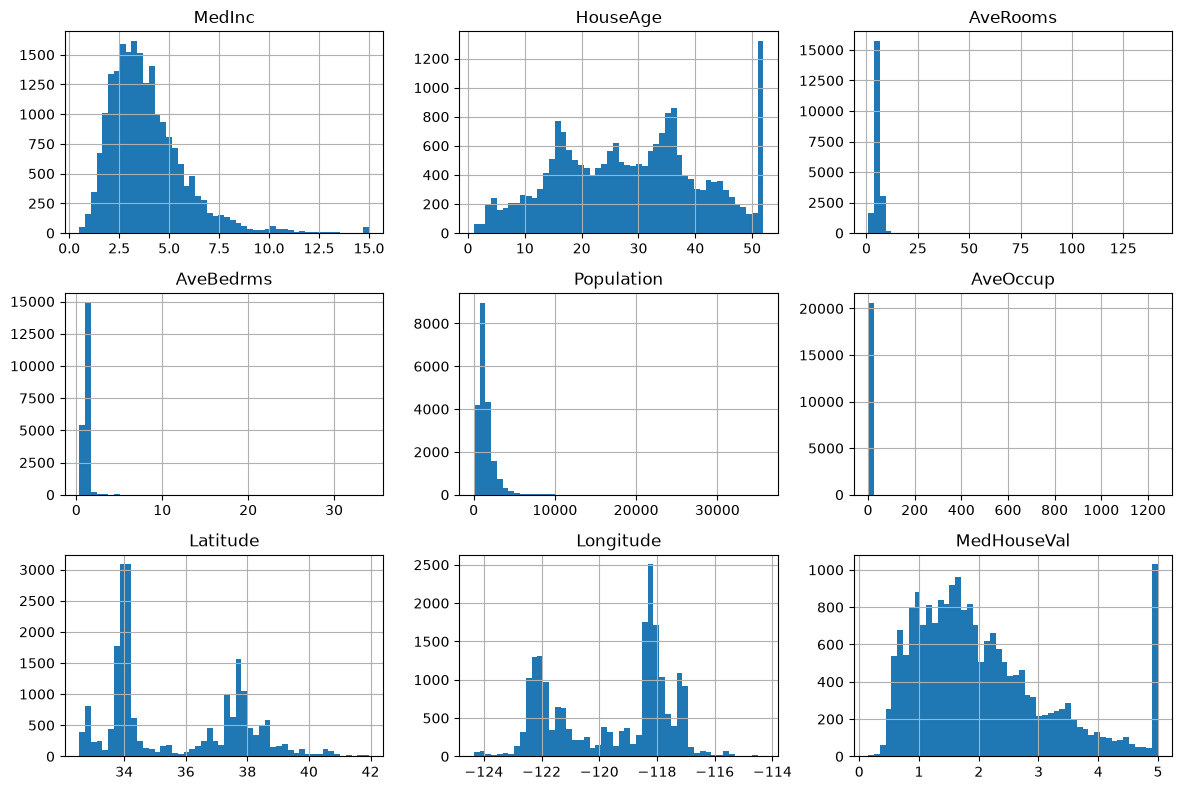

In [11]:
import matplotlib.pyplot as plt

housing.hist(bins=50, figsize=(12, 8))
plt.tight_layout()
plt.show()

### 3.2 Spotting a capped value in a histogram

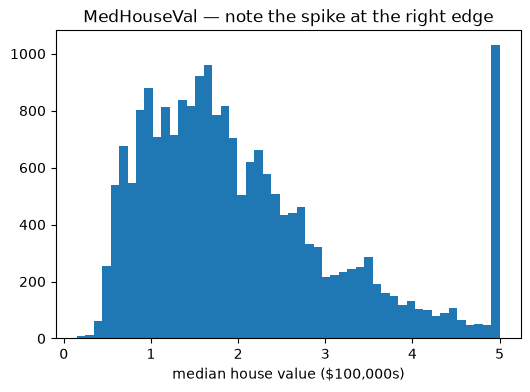

In [12]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(housing["MedHouseVal"], bins=50)
ax.set_title("MedHouseVal — note the spike at the right edge")
ax.set_xlabel("median house value ($100,000s)")
plt.show()

That spike at the far right is the censoring bug from Section 0.2, visible directly in the shape of the distribution. `HouseAge` has the same kind of spike at its own max (52) for the same reason — a data collection cap, not a real pattern in the world.

> **ML tie-in:** a histogram is often the fastest way to *see* a data quality issue that summary statistics only hint at.

## 4. Bivariate EDA: relationships between features
### 4.1 Correlation matrix

In [8]:
corr_matrix = housing.corr(numeric_only=True)
corr_matrix["MedHouseVal"].sort_values(ascending=False)

NameError: name 'housing' is not defined

### 4.2 Scatter matrix of the most correlated features

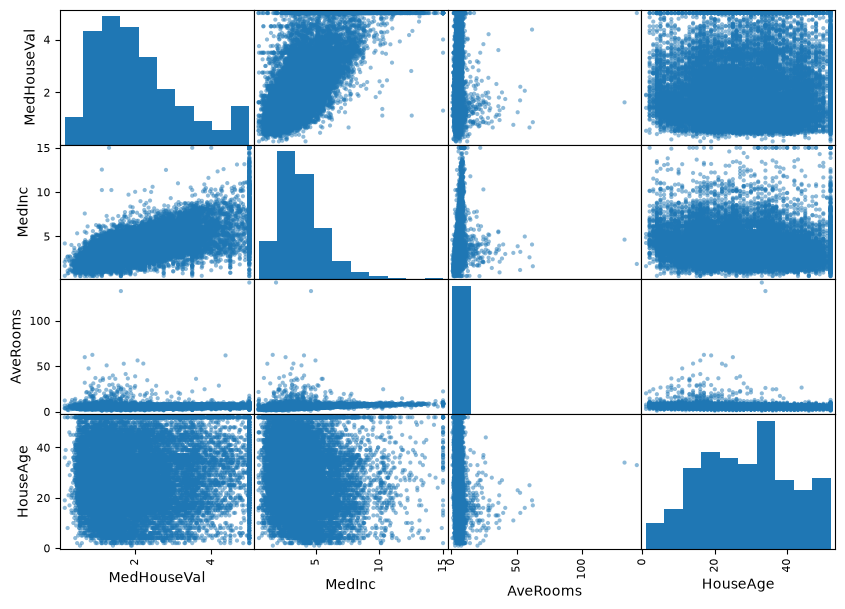

In [15]:
from pandas.plotting import scatter_matrix

attributes = ["MedHouseVal", "MedInc", "AveRooms", "HouseAge"]
scatter_matrix(housing[attributes], figsize=(10, 7))
plt.show()

### 4.3 Geographic scatter: latitude/longitude colored by price

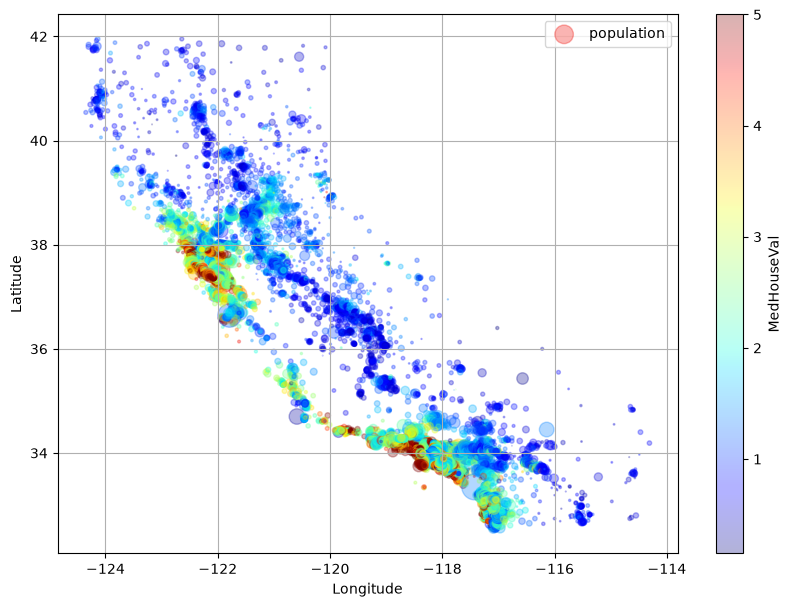

In [16]:
housing.plot(kind="scatter", x="Longitude", y="Latitude", grid=True,
             alpha=0.3, s=housing["Population"] / 100, label="population",
             c="MedHouseVal", cmap="jet", colorbar=True,
             legend=True, figsize=(10, 7))
plt.show()

> **ML tie-in:** `MedInc` (median income) is by far the strongest single predictor of `MedHouseVal` — that scatter plot in the matrix above is the one to remember. Geography also clearly matters (the coastal clusters in the map are visibly more expensive), even though `Latitude`/`Longitude` on their own correlate weakly with price — a hint that a later feature-engineering step (not covered here) could combine them into something more useful.

## 5. Missing values
### 5.1 Real data is rarely this clean

In [31]:
housing.isna().sum().sum()

np.int64(0)

Zero. `fetch_california_housing` ships pre-cleaned, which is convenient but not representative — a CSV pulled from a company database or downloaded from Kaggle will almost never look like this. To practice the actual skill, let's simulate what a messier version of this same data would look like: a copy with some values missing and a few duplicated rows, seeded so it's reproducible.

In [32]:
rng = np.random.default_rng(42)

messy = housing.copy()

missing_idx = rng.choice(messy.index, size=200, replace=False)
messy.loc[missing_idx, "AveBedrms"] = np.nan

missing_idx_2 = rng.choice(messy.index, size=120, replace=False)
messy.loc[missing_idx_2, "AveRooms"] = np.nan

messy.isna().sum()

MedInc           0
HouseAge         0
AveRooms       120
AveBedrms      200
Population       0
AveOccup         0
Latitude         0
Longitude        0
MedHouseVal      0
dtype: int64

### 5.2 Finding missing values

In [33]:
missing_pct = messy.isna().mean().sort_values(ascending=False) * 100
missing_pct[missing_pct > 0]

AveBedrms    0.968992
AveRooms     0.581395
dtype: float64

### 5.3 Option 1: drop the rows

In [34]:
option1 = messy.dropna(subset=["AveBedrms", "AveRooms"])
print("before:", messy.shape, " after:", option1.shape)

before: (20640, 9)  after: (20322, 9)


Simple, but it throws away every row that had *any* missing value in those columns — here, roughly 1.5% of the whole dataset, gone.

### 5.4 Option 2: drop the column

In [35]:
option2 = messy.drop(columns=["AveBedrms"])
option2.shape

(20640, 8)

No rows lost, but the entire `AveBedrms` feature is gone — fine if it wasn't useful, wasteful if it was.

### 5.5 Option 3: impute — fill the holes instead

In [36]:
option3 = messy.copy()
for col in ["AveBedrms", "AveRooms"]:
    median = option3[col].median()
    option3[col] = option3[col].fillna(median)

option3.isna().sum()

MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

This keeps every row and every column. `SimpleImputer` does the same thing, but fits the strategy once and can be reused on new data later — that reusability is exactly why it becomes a `Pipeline` step in a real project instead of a one-off `.fillna()` call:

In [37]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")
housing_num = messy.select_dtypes(include=[np.number])

imputer.fit(housing_num)
imputer.statistics_[:4]  # first few learned medians, one per numeric column

array([ 3.5348    , 29.        ,  5.22912879,  1.04878049])

> **ML tie-in:** there's no universally correct option among the three — it depends on how much missing data there is, whether it's missing at random, and how important the column is. What matters is making the choice deliberately and being able to say which one you made and why.

## 6. Duplicate rows
### 6.1 Finding them

In [39]:
dup_idx = rng.choice(messy.index, size=15, replace=False)
messy = pd.concat([messy, messy.loc[dup_idx]], ignore_index=True)

print("shape after re-adding some rows:", messy.shape)
print("duplicated rows:", messy.duplicated().sum())

shape after re-adding some rows: (20670, 9)
duplicated rows: 30


This kind of duplication is common after a join, a re-run data export, or an API that got called twice by mistake — the rows are individually valid, they just shouldn't be there twice.

### 6.2 Dropping them

In [40]:
housing_clean = messy.drop_duplicates()
print("before:", messy.shape, " after:", housing_clean.shape)

before: (20670, 9)  after: (20640, 9)


> **ML tie-in:** duplicated rows are a quiet way to leak the same example into both a train and a test split, which inflates the reported test score without the model actually generalizing any better.

## 7. Outliers
### 7.1 Back to those suspicious extremes

In [42]:
housing[["AveRooms", "AveOccup"]].describe()

,AveRooms,AveOccup
count,20640.000000,20640.000000
mean,5.429000,3.070655
std,2.474173,10.386050
min,0.846154,0.692308
25%,4.440716,2.429741
50%,5.229129,2.818116
75%,6.052381,3.282261
max,141.909091,1243.333333


In [43]:
housing.sort_values("AveOccup", ascending=False).head(3)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
19006,10.2264,45.0,3.166667,0.833333,7460.0,1243.333333,38.32,-121.98,1.375
3364,5.5179,36.0,5.142857,1.142857,4198.0,599.714286,40.41,-120.51,0.675
16669,4.2639,46.0,9.076923,1.307692,6532.0,502.461538,35.32,-120.70,3.500


One district reports ~1243 people per household on average — almost certainly a data entry error, not a real place. Compare it to the 75th percentile of ~3.3.

### 7.2 Visual check: boxplot

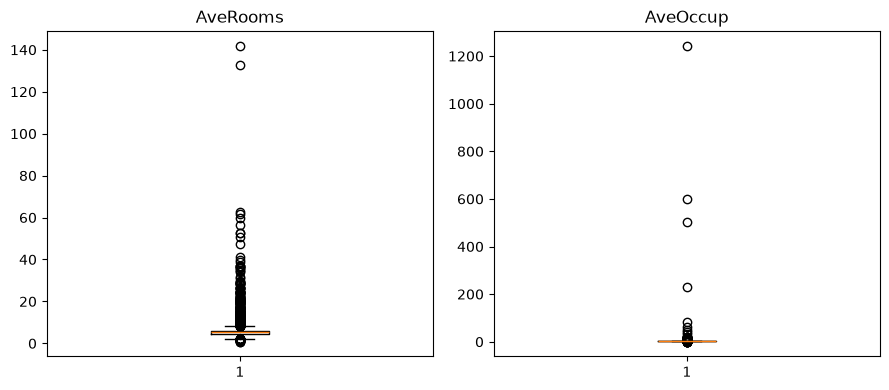

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(9, 4))
axes[0].boxplot(housing["AveRooms"])
axes[0].set_title("AveRooms")
axes[1].boxplot(housing["AveOccup"])
axes[1].set_title("AveOccup")
plt.tight_layout()
plt.show()

### 7.3 A rule of thumb: the IQR bound

In [45]:
q1, q3 = housing["AveOccup"].quantile([0.25, 0.75])
iqr = q3 - q1
upper_bound = q3 + 1.5 * iqr

outliers = housing[housing["AveOccup"] > upper_bound]
print(f"upper bound: {upper_bound:.2f}")
print(f"flagged as outliers: {len(outliers)} rows out of {len(housing)}")

upper bound: 4.56
flagged as outliers: 704 rows out of 20640


### 7.4 What to do about them

Flagging an outlier is not the same as automatically deleting it — sometimes it's a genuine data error (drop it), sometimes it's a rare-but-real district (keep it, or a model that's robust to outliers might be a better fit than removing the data). The right call depends on the domain, not on a fixed statistical rule. Later, tools like `sklearn.ensemble.IsolationForest` can automate this kind of detection across many columns at once — but the judgment call about what to do with what's flagged is still yours to make.

## 8. Feature scaling: putting features on the same footing
### 8.1 Why scale? Features live on wildly different numeric ranges

In [46]:
for col in ["MedInc", "Population", "AveRooms", "HouseAge"]:
    print(f"{col:<12} min={housing[col].min():>10.2f}   max={housing[col].max():>10.2f}")

MedInc       min=      0.50   max=     15.00
Population   min=      3.00   max=  35682.00
AveRooms     min=      0.85   max=    141.91
HouseAge     min=      1.00   max=     52.00


`Population` swings from 3 to almost 36,000. `MedInc` never leaves single digits. If you fed these raw numbers into an algorithm that measures *distance* between rows (like k-nearest neighbors) or one that takes *gradient steps* sized the same way in every direction (like plain gradient descent), `Population` would completely dominate — not because it's more important, just because its numbers are bigger. Scaling fixes that by putting every feature on a comparable footing, without changing what the data says.

No hand computation needed for any of this — we'll let `sklearn` do the arithmetic and focus on *reading the charts* to see what each scaler actually does.

### 8.2 `StandardScaler`: center on 0, scale to unit spread

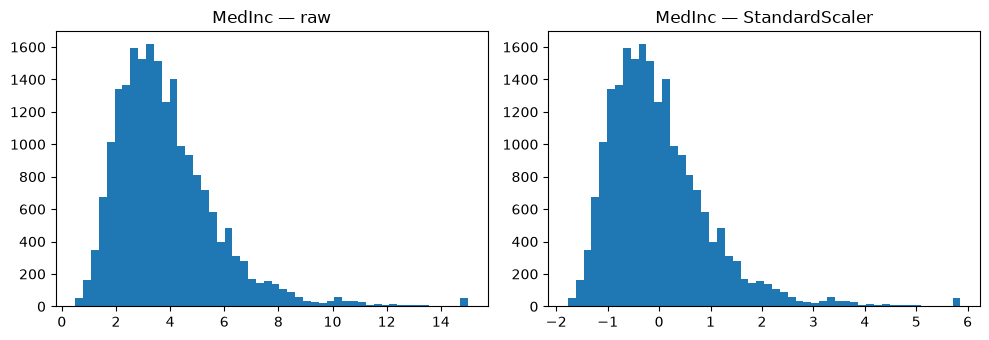

In [47]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
medinc_scaled = scaler.fit_transform(housing[["MedInc"]])

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].hist(housing["MedInc"], bins=50)
axes[0].set_title("MedInc — raw")
axes[1].hist(medinc_scaled, bins=50)
axes[1].set_title("MedInc — StandardScaler")
plt.tight_layout()
plt.show()

Same shape, same skew, same story — only the x-axis changed. The scaled version is centered on 0 (that's the *mean* moving to 0) and most values now land roughly between -2 and 3 (that's the *unit spread* — one unit on this new axis is one standard deviation of the original data).

### 8.3 `MinMaxScaler`: squash into [0, 1]

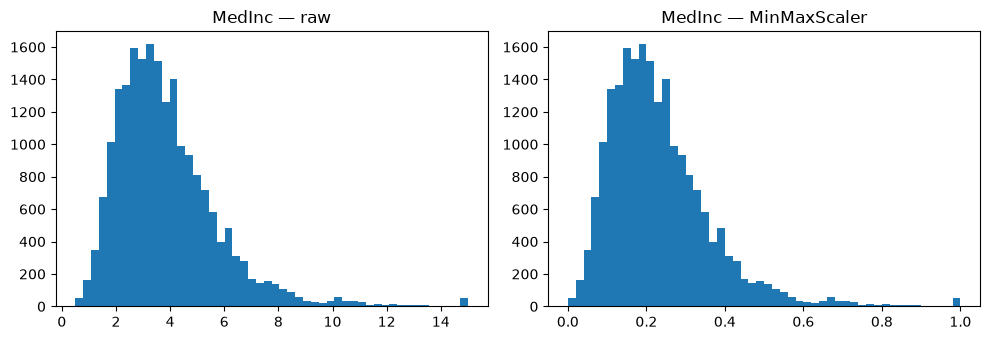

In [48]:
from sklearn.preprocessing import MinMaxScaler

minmax = MinMaxScaler()
medinc_minmax = minmax.fit_transform(housing[["MedInc"]])

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].hist(housing["MedInc"], bins=50)
axes[0].set_title("MedInc — raw")
axes[1].hist(medinc_minmax, bins=50)
axes[1].set_title("MedInc — MinMaxScaler")
plt.tight_layout()
plt.show()

Same shape again, but this time every value is squeezed between 0 (the old minimum) and 1 (the old maximum) — a hard, fixed range instead of a mean/spread.

### 8.4 The real payoff: several features scaled together

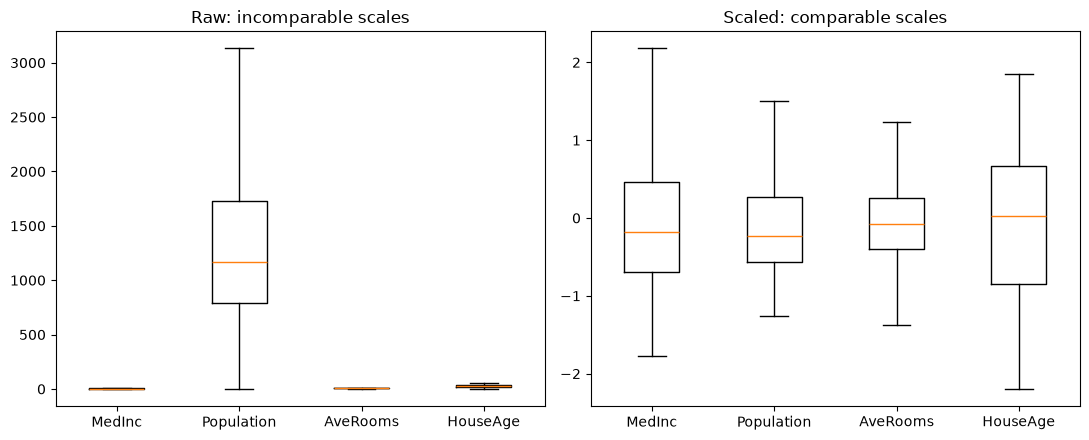

In [49]:
cols = ["MedInc", "Population", "AveRooms", "HouseAge"]
raw_cols = housing[cols]
scaled_cols = pd.DataFrame(StandardScaler().fit_transform(raw_cols), columns=cols)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].boxplot([raw_cols[c] for c in cols], tick_labels=cols, showfliers=False)
axes[0].set_title("Raw: incomparable scales")
axes[1].boxplot([scaled_cols[c] for c in cols], tick_labels=cols, showfliers=False)
axes[1].set_title("Scaled: comparable scales")
plt.tight_layout()
plt.show()

On the left, three of the four boxes are squashed into an invisible line at the bottom — `Population`'s scale is so much larger that it swallows the y-axis, and `MedInc`, `AveRooms`, and `HouseAge` might as well not exist on this chart. On the right, after scaling every column the same way, all four boxes are legible at once and none of them dominates just because of its raw units.

> **ML tie-in:** this is the concrete reason k-NN, k-means, PCA, SVMs, and gradient-descent-trained models (linear/logistic regression, neural networks) all expect scaled input — without it, whichever feature happens to have the largest raw units silently wins, exactly like `Population` just did to this chart.

### 8.5 `StandardScaler` vs `MinMaxScaler`: which one?

Both fix the same problem; they differ in how sensitive they are to outliers — which is exactly why Section 7 came before this one:

- **`MinMaxScaler`** anchors directly on the min and max. One extreme outlier (like the `AveOccup` district from Section 7) stretches the whole range, squashing every normal value into a tiny sliver near 0.
- **`StandardScaler`** uses the mean and standard deviation instead. Still pulled by outliers, but less violently, since one extreme point can't single-handedly set the boundary of the whole scale.

`StandardScaler` is the more common default for that reason. Reach for `MinMaxScaler` when you specifically need values in a fixed `[0, 1]` range — for example, some neural network layers expect bounded input.

### 8.6 A word of caution: "normalization" means two different things

People (and some libraries/tutorials) casually call `MinMaxScaler` "normalizing" a feature, since it squashes values into a fixed `[0, 1]` range. But `sklearn` reserves the name `Normalizer` for something else entirely: instead of rescaling each **column** (feature) the way every scaler above does, `Normalizer` rescales each **row** (sample) so that it has the same overall length, regardless of the other rows. It's a completely different axis of operation — column-wise vs. row-wise — and it's worth seeing so the two don't get confused.

Every single row, no matter how far it started from the origin, lands exactly on the circle after `Normalizer`. What's preserved is the **angle** — the ratio between `MedInc` and `AveRooms` for that district — and what's discarded is the **distance from the origin**, i.e. the overall magnitude. Two districts with wildly different incomes but the same *ratio* of income to rooms end up at the same point.

> **ML tie-in:** row-wise normalization is the right tool when what matters is a sample's *shape* or *direction* rather than its absolute scale — the classic case is text represented as word-count vectors, or embeddings compared by the angle between them (cosine similarity), where two documents should be considered similar regardless of length. It's rarely what you want on a table like this housing data, where absolute feature values (not just their ratios) carry real information — but knowing it exists, and that it answers a different question than `StandardScaler`/`MinMaxScaler`, avoids reaching for the wrong tool when the word "normalize" comes up.

## 9. From cleaning to modeling: what comes next

Everything above was done by hand, on purpose — seeing each step explicitly is how the choices involved actually stick. In a real project, once these choices are settled, they get wrapped into a reusable `Pipeline` (`SimpleImputer` + scaling + encoding, chained together) so the exact same cleaning is applied consistently to training data, test data, and any new data the model sees later. That's a topic for a future notebook — for now, the goal was just building the judgment to know *what* needs handling and *why*, before automating *how*.

## 10. Summary

### Cheat sheet

| Task | Tool |
|---|---|
| Shape and dtypes | `df.shape`, `df.info()`, `df.dtypes` |
| Statistical summary | `df.describe()` |
| Distribution of one feature | `df.hist(bins=...)`, `ax.hist(...)` |
| Correlation with the target | `df.corr(numeric_only=True)["target"]` |
| Relationships between features | `pandas.plotting.scatter_matrix(df[cols])` |
| Geographic / colored scatter | `df.plot(kind="scatter", x=..., y=..., c=..., cmap=...)` |
| Find missing values | `df.isna().sum()`, `df.isna().mean()` |
| Handle missing values | `df.dropna(subset=[...])`, `df.drop(columns=[...])`, `df[col].fillna(median)`, `SimpleImputer` |
| Find duplicate rows | `df.duplicated().sum()` |
| Drop duplicate rows | `df.drop_duplicates()` |
| Spot outliers | `df.describe()`, `ax.boxplot(...)`, IQR bound (`q3 + 1.5*iqr`) |
| Standardize (mean 0, spread 1), column-wise | `StandardScaler().fit_transform(df[cols])` |
| Scale to a fixed [0, 1] range, column-wise | `MinMaxScaler().fit_transform(df[cols])` |
| Rescale each row to unit length | `Normalizer().fit_transform(df[cols])` |


## 11. Exercises

Use only what this notebook covered.

1. Load `fetch_california_housing(as_frame=True).frame` fresh. Report, in one line each: its shape, how many missing values it has, and how many duplicated rows it has.
2. Using `rng = np.random.default_rng(0)`, create a messy copy of the housing DataFrame with 5% of the values in `"Population"` set to `NaN`. Report the exact count of missing values this created.
3. On that same messy copy, compare the mean of `"Population"` under two strategies: dropping the missing rows vs. filling them with the median. Are the two means close or far apart? Why might that be?
4. `HouseAge` is capped at 52, the same way `MedHouseVal` is capped at 5.00001. Plot its histogram and report what fraction of rows sit exactly at the cap.
5. Using the IQR rule from Section 7.3, find the upper outlier bound for `"AveRooms"` and report how many rows in the (original, clean) `housing` DataFrame exceed it.
6. Plot a histogram of `"AveRooms"` raw, then again after `StandardScaler` and after `MinMaxScaler` (three panels, side by side). Which of the two scalers gets visibly distorted by the outliers from Section 7, and how can you tell just by looking at the chart?
7. Take `housing[["MedInc", "Population"]].sample(300, random_state=0)`, apply `Normalizer`, and plot the result with a unit circle like Section 8.6. Then apply `StandardScaler` to the *same* sample instead and plot that. Explain in one sentence why the `StandardScaler` result does *not* form a circle the way the `Normalizer` one does.